# MESA-GEO ABM

## Import packages

In [1]:
from scorefilter import EnSF
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import os
if os.path.split(os.getcwd())[1] == 'geo':
    os.chdir('..')
import geo.model

In [2]:
def check_paramater(input_para):
    input_para[input_para<0.01] = 0.01
    input_para[input_para>0.99] = 0.99
    return input_para


def sir_balance(S, I, R):
    """
    Fixes negative values in S by transferring them evenly to I and R.
    Assumes S, I, R are integer arrays of the same shape.
    """
    S = S.copy()
    I = I.copy()
    R = R.copy()
    total_before = S + I + R

    # Find where S is negative
    negative_mask = S < 0
    negative_values = -S[negative_mask]  # amount to fix (positive)
    
    # Split negative values evenly to I and R
    half = negative_values // 2
    remainder = negative_values % 2  # handle odd case

    I[negative_mask] -= half             #.  negative_values    
    R[negative_mask] -= half + remainder  # send the extra to R

    S[negative_mask] = 0  # set negatives to zero
    I, R ,S = re_balance(I, R ,S)
    R, I, S  = re_balance(R, I, S)
    

    # Final checks
    error_found = False

    if not np.all(S >= 0):
        print("❌ Error: Negative values remain in S at positions:", np.argwhere(S < 0))
        error_found = True
    if not np.all(I >= 0):
        print("❌ Error: Negative values found in I at positions:", np.argwhere(I < 0))
        error_found = True
    if not np.all(R >= 0):
        print("❌ Error: Negative values found in R at positions:", np.argwhere(R < 0))
        error_found = True

    total_after = S + I + R
    if not np.array_equal(total_before, total_after):
        print("❌ Error: Total population not conserved at some grid points.")
        diff = total_after - total_before
        print(diff.shape)
        print("   Difference (after - before):\n", diff)
        error_found = True

    if error_found:
        raise ValueError("Fixing failed due to errors above.")
    return S, I, R

def re_balance(S, I, R):
    """
    Fixes negative values in S by transferring them evenly to I and R.
    Assumes S, I, R are integer arrays of the same shape.
    """
    S = S.copy()
    I = I.copy()
    R = R.copy()

    # Find where S is negative
    negative_mask = S < 0
    negative_values = -S[negative_mask]  # amount to fix (positive)

    I[negative_mask] -= negative_values
    S[negative_mask] = 0  # set negatives to zero

    return S, I, R

def get_agents(agent_list):
    matrix = np.zeros((20, 20, 6), dtype=int)
    # Fill in the data
    for item in agent_list:
        x, y = item['coordinate']
        state = item['disease_state']
        new_state = item['new_state']
        matrix[x, y, state] += 1
        matrix[x, y, new_state + 3] += 1
    return matrix

## initialize the model

In [3]:
#model set up
assim_time = 100
ens_size = 108
model_truth_seed = 50
geo_num_measures=100
Use_this_GPU = "cuda:0"

In [4]:
#initialize the model

#ground truth
shared_params = dict(
    cycle_period=3,
    max_travel_distance=3,
    selection_length=1,
    incubation_period=1,
)
model = geo.model.GeoDiseaseModel(
    **shared_params,
    pop_density=100,
    hub_density=50,
    num_measures=geo_num_measures,
    num_initial_infected=10
)
model.random.seed(666)                 # Python random (agent scheduling, etc.)
model.rng = np.random.default_rng(666) # NumPy RNG (movement, sampling)
#seed
ground_truth_seed = np.random.default_rng(model_truth_seed)

#paramater for ground truth
p_shape = model.get_spread_chance().shape
spread_chance_gt = ground_truth_seed.uniform(low=0.499, high=0.50001, size=p_shape) #0.5 
recovery_chance_gt = ground_truth_seed.uniform(low=0.199, high=0.2001, size=p_shape) #0.2.
gain_resistance_chance_gt =  ground_truth_seed.uniform(low=0.099, high=0.10005, size=p_shape) #0.1
model.set_spread_chance(spread_chance_gt)
model.set_recovery_chance(recovery_chance_gt)
model.set_gain_resistance_chance(gain_resistance_chance_gt)
#print(model.get_spread_chance())

measure_location_zip = model.get_measurement_sites_by_neighborhood()

In [5]:
# save the ground truth model
model_truth_copy = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)  
model_truth_copy.load_state(model.dump_state())
model_truth_copy.random.seed(666)                 
model_truth_copy.rng = np.random.default_rng(666) 
model_truth_copy.set_spread_chance(spread_chance_gt)
model_truth_copy.set_recovery_chance(recovery_chance_gt)
model_truth_copy.set_gain_resistance_chance(gain_resistance_chance_gt)

In [6]:
#wrong guess
spread_chance_ens = check_paramater(ground_truth_seed.normal(loc = 0.3,scale = 0.1,size=(ens_size,p_shape[0])))
recovery_chance_ens = check_paramater(ground_truth_seed.normal(loc = 0.4,scale = 0.1,size=(ens_size,p_shape[0])))
gain_resistance_chance_ens = gain_resistance_chance_gt
grid_locations = np.array([m.geometry.xy for m in model.measurement_sites])[:, :, 0]

In [7]:
#mirco_plot
wrong_spread_chance = np.ones_like(spread_chance_gt) * 0.3
wrong_recovery_chance = np.ones_like(spread_chance_gt) * 0.4

model_plot_noda = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
model_plot_noda.load_state(model.dump_state())
model_plot_noda.set_spread_chance(wrong_spread_chance)
model_plot_noda.set_recovery_chance(wrong_recovery_chance)

error_plot_noda = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
error_plot_noda.load_state(model.dump_state())

model_plot_case2 = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
model_plot_case2.load_state(model.dump_state())
model_plot_case2.set_spread_chance(wrong_spread_chance)
model_plot_case2.set_recovery_chance(wrong_recovery_chance)

error_plot_case2 = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
error_plot_case2.load_state(model.dump_state())

model_plot_case3 = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
model_plot_case3.load_state(model.dump_state())
model_plot_case3.set_spread_chance(wrong_spread_chance)
model_plot_case3.set_recovery_chance(wrong_recovery_chance)

error_plot_case3 = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)
error_plot_case3.load_state(model.dump_state())

In [8]:
#save ground_truth
truth_state = np.zeros((assim_time+1,geo_num_measures,3))
truth_state[0,:,0] = geo.model.measure_local_susceptible(model)
truth_state[0,:,1] = geo.model.measure_local_infected(model)
truth_state[0,:,2] = geo.model.measure_local_resistant(model)
truth_agent_states   = []
truth_agent_x        = []
truth_agent_y        = []

for t in range(assim_time):
    # Save before stepping the model
    states_t = []
    xs_t = []
    ys_t = []
    for person in model.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    truth_agent_states.append(states_t)
    truth_agent_x.append(xs_t)
    truth_agent_y.append(ys_t)
    # Step
    model.step()
    truth_state[t+1,:,0] = geo.model.measure_local_susceptible(model)
    truth_state[t+1,:,1] = geo.model.measure_local_infected(model)
    truth_state[t+1,:,2] = geo.model.measure_local_resistant(model)

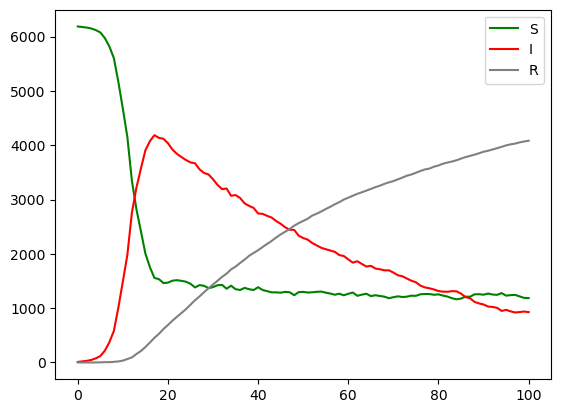

In [9]:
#plot truth
plt.plot(truth_state[...,0].sum(axis=1), c='green', label='S')
plt.plot(truth_state[...,1].sum(axis=1), c='red', label='I')
plt.plot(truth_state[...,2].sum(axis=1), c='gray', label='R')
plt.legend()
plt.show()

In [10]:
#observation
obs_state = np.zeros((assim_time,geo_num_measures,3))
error_level = 0.1
obs_std = np.zeros((assim_time,geo_num_measures,3))
obs_std[...,1] = error_level* truth_state[1:,...,1]
obs_std[...,2] = error_level* truth_state[1:,...,2]

obs_state[...,1] = truth_state[1:,...,1] +  np.round(ground_truth_seed.normal(loc = 0,scale = obs_std[...,1],size=(assim_time,geo_num_measures))).astype(int)
np.maximum(obs_state[...,1], 0, out=obs_state[...,1])
obs_state[...,2] = truth_state[1:,...,2] +  np.round(ground_truth_seed.normal(loc = 0,scale = obs_std[...,2],size=(assim_time,geo_num_measures))).astype(int)
np.maximum(obs_state[...,2], 0, out=obs_state[...,2])
obs_state[...,0] = truth_state[1:,...].sum(axis=(2)) - obs_state[...,1] - obs_state[...,2]
obs_state[...,0],obs_state[...,1],obs_state[...,2] = sir_balance(obs_state[...,0],obs_state[...,1],obs_state[...,2])
obs_std[obs_std<0.1] = 0.1

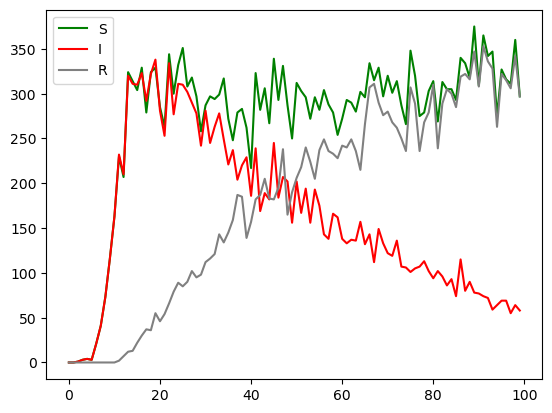

In [11]:
#plot observation error
from matplotlib.lines import lineStyles
plt.plot(np.abs(obs_state[...,0]-truth_state[1:,...,0]).sum(axis=1), c='green', label='S')
plt.plot(np.abs(obs_state[...,1]-truth_state[1:,...,1]).sum(axis=1), c='red', label='I')
plt.plot(np.abs(obs_state[...,2]-truth_state[1:,...,2]).sum(axis=1), c='gray', label='R')
plt.legend()
plt.show()

## Case 1 -- Model Only

In [ ]:
#ensembles
models = {}
# pop_density=None to avoid slow initialization, then copy ground truth initial state
for i in range(ens_size):
    models[f"ens_{i}"] = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)  
    models[f"ens_{i}"].load_state(model_truth_copy.dump_state())
    # Now randomize the model parameters to be a bit different from the ground truth parameters
    models[f"ens_{i}"].set_spread_chance(spread_chance_ens[i])
    models[f"ens_{i}"].set_recovery_chance(recovery_chance_ens[i])

In [ ]:
ens_noda = np.zeros((assim_time+1,ens_size,geo_num_measures,3))
noda_agent_states         = []
noda_agent_x              = []
noda_agent_y              = []
error_noda_agent_states   = []
error_noda_agent_x        = []
error_noda_agent_y        = []

for i in range(ens_size):
    ens_noda[0,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
    ens_noda[0,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
    ens_noda[0,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
for t in range(assim_time):
    #save plot agent
    S = ens_noda[t,:,:,0].mean(axis=0).astype(int)
    I = ens_noda[t,:,:,1].mean(axis=0).astype(int)
    R = ens_noda[t,:,:,2].mean(axis=0).astype(int)
    model_plot_noda.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in model_plot_noda.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    noda_agent_states.append(states_t)
    noda_agent_x.append(xs_t)
    noda_agent_y.append(ys_t)    
    #save error plot agent
    I = np.abs(ens_noda[t,:,:,1].mean(axis=0)-truth_state[t,:,1]).astype(int)
    R = np.abs(ens_noda[t,:,:,2].mean(axis=0)-truth_state[t,:,2]).astype(int)
    S = np.abs(truth_state[t,:,:].sum(axis=1)-I-R).astype(int)
    error_plot_noda.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in error_plot_noda.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    error_noda_agent_states.append(states_t)
    error_noda_agent_x.append(xs_t)
    error_noda_agent_y.append(ys_t)   
    # Step
    model_plot_noda.step()
    #error_plot_noda.step()
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_noda[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_noda[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_noda[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])

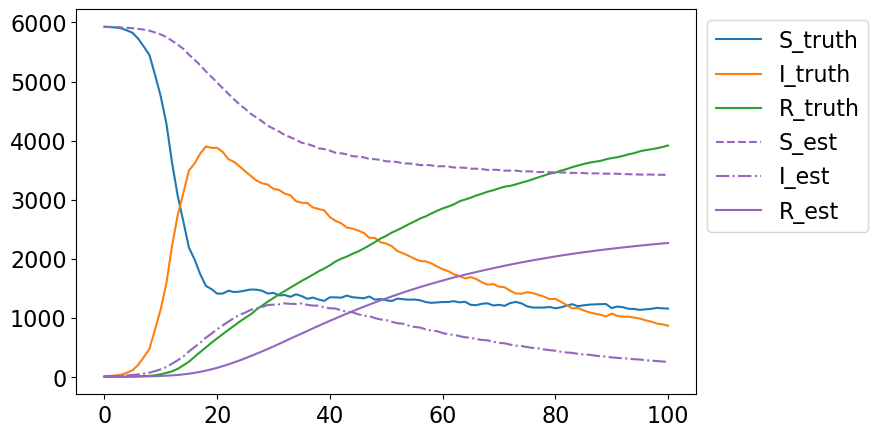

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[...,0].sum(axis=(1)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[...,1].sum(axis=(1)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[...,2].sum(axis=(1)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_noda[...,0].mean(axis=1).sum(axis=(1)),label = "S_est", color='tab:purple', linestyle='--')
plt.plot(ens_noda[...,1].mean(axis=1).sum(axis=(1)),label = "I_est", color='tab:purple', linestyle='-.')
plt.plot(ens_noda[...,2].mean(axis=1).sum(axis=(1)),label = "R_est", color='tab:purple', linestyle='-')
#plt.title("ABM only without DA", fontsize=18)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16)
plt.tick_params(axis="both", labelsize=16)
plt.show()

## Case 2 -- State estimation via EnSF

In [ ]:
#ensembles
models = {}
# pop_density=None to avoid slow initialization, then copy ground truth initial state
for i in range(ens_size):
    models[f"ens_{i}"] = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)  
    models[f"ens_{i}"].load_state(model_truth_copy.dump_state())
    # Now randomize the model parameters to be a bit different from the ground truth parameters
    models[f"ens_{i}"].set_spread_chance(spread_chance_ens[i])
    models[f"ens_{i}"].set_recovery_chance(recovery_chance_ens[i])

In [ ]:
#case 2
ens_state_case2 = np.zeros((assim_time+1,ens_size,geo_num_measures,3))
ens_prior_case2 = np.zeros((assim_time+1,ens_size,geo_num_measures,3))
case2_agent_states         = []
case2_agent_x              = []
case2_agent_y              = []
error_case2_agent_states   = []
error_case2_agent_x        = []
error_case2_agent_y        = [] 

for i in range(ens_size):
    ens_state_case2[0,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
    ens_state_case2[0,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
    ens_state_case2[0,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
ens_prior_case2[0] = ens_state_case2[0].copy()

ens_state_case2_sum = ens_state_case2[0].sum(axis=2)
EnSF_Update_state = EnSF(n_dim = geo_num_measures*2, ensemble_size = ens_size ,eps_alpha=0.05, device= Use_this_GPU ,\
                   obs_sigma = obs_std[0,...,1:3].reshape(geo_num_measures*2), euler_steps = 1000, scalefact = 1, init_std_x_state = 2,  ISarctan=False)

for t in range(assim_time):   #assim_time
    #save plot agent
    S = ens_state_case2[t,:,:,0].mean(axis=0).astype(int)
    I = ens_state_case2[t,:,:,1].mean(axis=0).astype(int)
    R = ens_state_case2[t,:,:,2].mean(axis=0).astype(int)
    model_plot_case2.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in model_plot_case2.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    case2_agent_states.append(states_t)
    case2_agent_x.append(xs_t)
    case2_agent_y.append(ys_t)    
    #save error plot agent
    I = np.abs(ens_state_case2[t,:,:,1].mean(axis=0)-truth_state[t,:,1]).astype(int)
    R = np.abs(ens_state_case2[t,:,:,2].mean(axis=0)-truth_state[t,:,2]).astype(int)
    S = np.abs(truth_state[t,:,:].sum(axis=1)-I-R).astype(int)
    error_plot_case2.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in error_plot_case2.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    error_case2_agent_states.append(states_t)
    error_case2_agent_x.append(xs_t)
    error_case2_agent_y.append(ys_t)   
    # Step
    model_plot_case2.step()
    #error_plot_case2.step()
    print("now is time" ,  t)
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state_case2[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state_case2[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_state_case2[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_prior_case2[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])

    if t< 30:
        pre_inf = np.random.normal(loc=0.0, scale=1, size=ens_state_case2[t+1, :, :, 1:3].shape)
        ens_state_case2[t+1,:,:,1:3] += pre_inf
        xens = EnSF_Update_state.state_update_normalized(x_input= ens_state_case2[t+1,:,:,1:3].reshape(ens_size,geo_num_measures*2), \
                                                        obs_input= obs_state[t,...,1:3].reshape(geo_num_measures*2), sparse_idx = np.arange(geo_num_measures*2),arcindex= np.array([], dtype=int))
        xens = xens.cpu().numpy().reshape(ens_size,geo_num_measures,2)
        xens[xens<0] = 0
        ens_state_case2[t+1,:,:,1] = np.round(xens[...,0])
        ens_state_case2[t+1,:,:,2] = np.round(xens[...,1])
        ens_state_case2[t+1,:,:,0] = (ens_state_case2_sum - ens_state_case2[t+1,:,:,1] - ens_state_case2[t+1,:,:,2])
        ens_state_case2[t+1,:,:,0], ens_state_case2[t+1,:,:,1], ens_state_case2[t+1,:,:,2] = sir_balance(ens_state_case2[t+1,:,:,0], ens_state_case2[t+1,:,:,1], ens_state_case2[t+1,:,:,2])
        S = ens_state_case2[t+1,:,:,0].astype(int)
        I = ens_state_case2[t+1,:,:,1].astype(int)
        R = ens_state_case2[t+1,:,:,2].astype(int)
        for i in range(ens_size):
            models[f"ens_{i}"].match_sir_statistics(S[i], I[i], R[i])

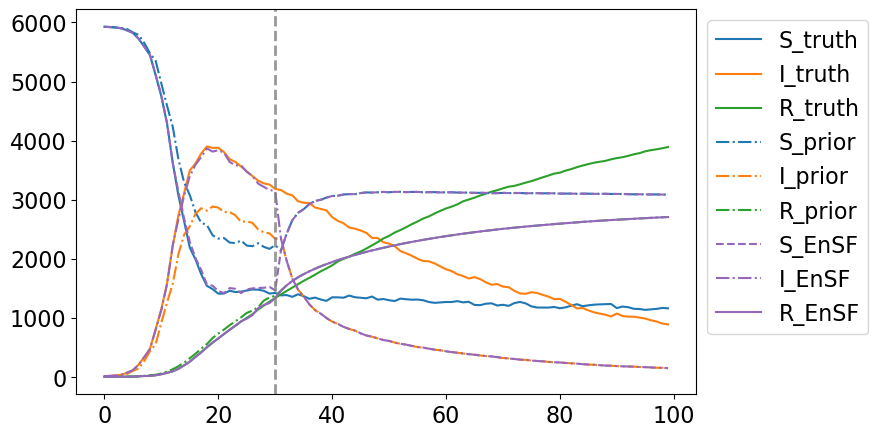

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[:100,...,0].sum(axis=(1)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[:100,...,1].sum(axis=(1)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[:100,...,2].sum(axis=(1)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_prior_case2[:100,...,0].mean(axis=1).sum(axis=(1)),label = "S_prior", color='tab:blue', linestyle='-.')
plt.plot(ens_prior_case2[:100,...,1].mean(axis=1).sum(axis=(1)),label = "I_prior", color='tab:orange', linestyle='-.')
plt.plot(ens_prior_case2[:100,...,2].mean(axis=1).sum(axis=(1)),label = "R_prior", color='tab:green', linestyle='-.')
plt.plot(ens_state_case2[:100,...,0].mean(axis=1).sum(axis=(1)),label = "S_EnSF", color='tab:purple', linestyle='--')
plt.plot(ens_state_case2[:100,...,1].mean(axis=1).sum(axis=(1)),label = "I_EnSF", color='tab:purple', linestyle='-.')
plt.plot(ens_state_case2[:100,...,2].mean(axis=1).sum(axis=(1)),label = "R_EnSF", color='tab:purple', linestyle='-')

plt.axvline(x=30, color='tab:gray', linestyle='--', alpha=0.8, linewidth=2)
# plt.text(15, 3800, 'DA Phase', ha='center', fontsize=12, 
#          bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
# plt.text(60, 3800, 'Prediction Phase', ha='center', fontsize=12,
#          bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcyan", alpha=0.8))
#plt.title("ABM with DA (State Only)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16)
plt.tick_params(axis="both", labelsize=16)
plt.show()

## Case 3 -- joint state estimation and parameter estimation via EnSF

In [12]:
#ensembles
models = {}
# pop_density=None to avoid slow initialization, then copy ground truth initial state
for i in range(ens_size):
    models[f"ens_{i}"] = geo.model.GeoDiseaseModel(**shared_params, pop_density=None)  
    models[f"ens_{i}"].load_state(model_truth_copy.dump_state())
    # Now randomize the model parameters to be a bit different from the ground truth parameters
    models[f"ens_{i}"].set_spread_chance(spread_chance_ens[i])
    models[f"ens_{i}"].set_recovery_chance(recovery_chance_ens[i])

In [ ]:
ens_state = np.zeros((assim_time+1,ens_size,geo_num_measures,3))
ens_parameter = np.zeros((assim_time+1,ens_size,p_shape[0],2))
ens_prior = np.zeros((assim_time+1,ens_size,geo_num_measures,3))
case3_agent_states         = []
case3_agent_x              = []
case3_agent_y              = []
error_case3_agent_states   = []
error_case3_agent_x        = []
error_case3_agent_y        = [] 

for i in range(ens_size):
    ens_state[0,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
    ens_state[0,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
    ens_state[0,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
    ens_parameter[0,i,:,0] = models[f"ens_{i}"].get_spread_chance()
    ens_parameter[0,i,:,1] = models[f"ens_{i}"].get_recovery_chance()
ens_state_sum = ens_state[0].sum(axis=2)
ens_prior[0] = ens_state[0].copy()

EnSF_Update_state = EnSF(n_dim = geo_num_measures*2, ensemble_size = ens_size ,eps_alpha=0.05, device= Use_this_GPU ,\
                   obs_sigma = obs_std[0,...,1:3].reshape(geo_num_measures*2), euler_steps = 1000, scalefact = 1, init_std_x_state = 2,  ISarctan=False)

EnSF_Update_para = EnSF(n_dim = p_shape[0]*2, ensemble_size = ens_size ,eps_alpha=0.05, device= Use_this_GPU ,\
                   obs_sigma = 0.05, euler_steps = 1000, scalefact = 1, init_std_x_state = 0.1,  ISarctan=False)

for t in range(30):   #assim_time
    #save plot agent
    S = ens_state[t,:,:,0].mean(axis=0).astype(int)
    I = ens_state[t,:,:,1].mean(axis=0).astype(int)
    R = ens_state[t,:,:,2].mean(axis=0).astype(int)
    model_plot_case3.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in model_plot_case3.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    case3_agent_states.append(states_t)
    case3_agent_x.append(xs_t)
    case3_agent_y.append(ys_t)    
    #save error plot agent
    I = np.abs(ens_state[t,:,:,1].mean(axis=0)-truth_state[t,:,1]).astype(int)
    R = np.abs(ens_state[t,:,:,2].mean(axis=0)-truth_state[t,:,2]).astype(int)
    S = np.abs(truth_state[t,:,:].sum(axis=1)-I-R).astype(int)
    error_plot_case3.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in error_plot_case3.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    error_case3_agent_states.append(states_t)
    error_case3_agent_x.append(xs_t)
    error_case3_agent_y.append(ys_t)   

    # Step
    model_plot_case3.step()
    #error_plot_case3.step()
    print("now is time" ,  t)
    EnSF_Update_para.init_std_x_state = 0.15 - 0.05*i/60 
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_state[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_prior[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
 
    #DA for state variables
    pre_inf = np.random.normal(loc=0.0, scale=1, size=ens_state[t+1, :, :, 1:3].shape)
    ens_state[t+1,:,:,1:3] += pre_inf
    xens = EnSF_Update_state.state_update_normalized(x_input= ens_state[t+1,:,:,1:3].reshape(ens_size,geo_num_measures*2), \
                                                     obs_input= obs_state[t,...,1:3].reshape(geo_num_measures*2), sparse_idx = np.arange(geo_num_measures*2),arcindex= np.array([], dtype=int))
    xens = xens.cpu().numpy().reshape(ens_size,geo_num_measures,2)
    xens[xens<0] = 0
    ens_state[t+1,:,:,1] = np.round(xens[...,0])
    ens_state[t+1,:,:,2] = np.round(xens[...,1])
    ens_state[t+1,:,:,0] = (ens_state_sum - ens_state[t+1,:,:,1] - ens_state[t+1,:,:,2])
    ens_state[t+1,:,:,0], ens_state[t+1,:,:,1], ens_state[t+1,:,:,2] = sir_balance(ens_state[t+1,:,:,0], ens_state[t+1,:,:,1], ens_state[t+1,:,:,2])
    S = ens_state[t+1,:,:,0].astype(int)
    I = ens_state[t+1,:,:,1].astype(int)
    R = ens_state[t+1,:,:,2].astype(int)

    for i in range(ens_size):
        models[f"ens_{i}"].match_sir_statistics(S[i], I[i], R[i])

    #DA for parameters
    for i in range(ens_size):
        ens_parameter[t+1,i,:,0] = models[f"ens_{i}"].get_spread_chance()
        ens_parameter[t+1,i,:,1] = models[f"ens_{i}"].get_recovery_chance()
    
    likelihoods_zip = np.zeros((ens_size,p_shape[0],2))
    for i in range(p_shape[0]):
        ens_state_std = np.abs(np.transpose(ens_prior[t+1,:,measure_location_zip[i],1:3], (1, 0, 2)) - xens[:,measure_location_zip[i],:].mean(axis=0)).sum(axis=1).mean(axis=0) * 0.5
        likelihoods_zip[:,i,:] = (1 / (np.sqrt(2 * np.pi) * ens_state_std)) * np.exp(-0.5 * ((np.transpose(ens_prior[t+1,:,measure_location_zip[i],1:3], (1, 0, 2)).sum(axis=1)- xens[:,measure_location_zip[i],:].sum(axis=1).mean(axis=0)) / ens_state_std) ** 2)   
    weights = likelihoods_zip / np.sum(likelihoods_zip,axis = 0)
    para_avg = (ens_parameter[t+1] * weights).sum(axis=0)
    para_ens = EnSF_Update_para.parameter_update(parameter_input= ens_parameter[t+1,:,:,:].reshape(ens_size,p_shape[0]*2), \
                                                    obs_input= para_avg.reshape(p_shape[0]*2))
    para_ens = check_paramater(para_ens.cpu().numpy().reshape(ens_size,p_shape[0],2))

    for i in range(ens_size):
        ens_parameter[t+1,i,:,0] = para_ens[i,:,0]
        ens_parameter[t+1,i,:,1] = para_ens[i,:,1]
        models[f"ens_{i}"].set_spread_chance(ens_parameter[t+1,i,:,0])
        models[f"ens_{i}"].set_recovery_chance(ens_parameter[t+1,i,:,1])
    model_plot_case3.set_spread_chance(ens_parameter[t+1,:,:,0].mean(axis=0))
    model_plot_case3.set_recovery_chance(ens_parameter[t+1,:,:,1].mean(axis=0))

I_avg = np.round(ens_state[t+1,:,:,1].mean(axis=0)).astype(int)
R_avg = np.round(ens_state[t+1,:,:,2].mean(axis=0)).astype(int)
S_avg = (ens_state_sum[0] - I_avg  - R_avg ).astype(int)
S_avg, I_avg, R_avg =(sir_balance(S_avg, I_avg, R_avg))
for i in range(ens_size):
    models[f"ens_{i}"].set_spread_chance(ens_parameter[t+1,:,:,0].mean(axis=0)) #
    models[f"ens_{i}"].set_recovery_chance(ens_parameter[t+1,:,:,1].mean(axis=0))  #

model_plot_case3.set_spread_chance(ens_parameter[t+1,:,:,0].mean(axis=0))
model_plot_case3.set_recovery_chance(ens_parameter[t+1,:,:,1].mean(axis=0))

for t in range(30,100):   #assim_time
    #save plot agent
    S = ens_state[t,:,:,0].mean(axis=0).astype(int)
    I = ens_state[t,:,:,1].mean(axis=0).astype(int)
    R = ens_state[t,:,:,2].mean(axis=0).astype(int)
    model_plot_case3.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in model_plot_case3.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    case3_agent_states.append(states_t)
    case3_agent_x.append(xs_t)
    case3_agent_y.append(ys_t)    
    #save error plot agent
    I = np.abs(ens_state[t,:,:,1].mean(axis=0)-truth_state[t,:,1]).astype(int)
    R = np.abs(ens_state[t,:,:,2].mean(axis=0)-truth_state[t,:,2]).astype(int)
    S = np.abs(truth_state[t,:,:].sum(axis=1)-I-R).astype(int)
    error_plot_case3.match_sir_statistics(S, I, R)
    states_t = []
    xs_t = []
    ys_t = []
    for person in error_plot_case3.all_people:
        states_t.append(person.state)
        x_arr, y_arr = person.geometry.xy
        xs_t.append(x_arr[0])
        ys_t.append(y_arr[0])

    error_case3_agent_states.append(states_t)
    error_case3_agent_x.append(xs_t)
    error_case3_agent_y.append(ys_t)   

    # Step
    model_plot_case3.step()
    # Step
    print("now is time" ,  t)
    for i in range(ens_size):
        models[f"ens_{i}"].step()
        ens_state[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_state[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_state[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])
        ens_prior[t+1,i,:,0] = geo.model.measure_local_susceptible(models[f"ens_{i}"])
        ens_prior[t+1,i,:,1] = geo.model.measure_local_infected(models[f"ens_{i}"])
        ens_prior[t+1,i,:,2] = geo.model.measure_local_resistant(models[f"ens_{i}"])

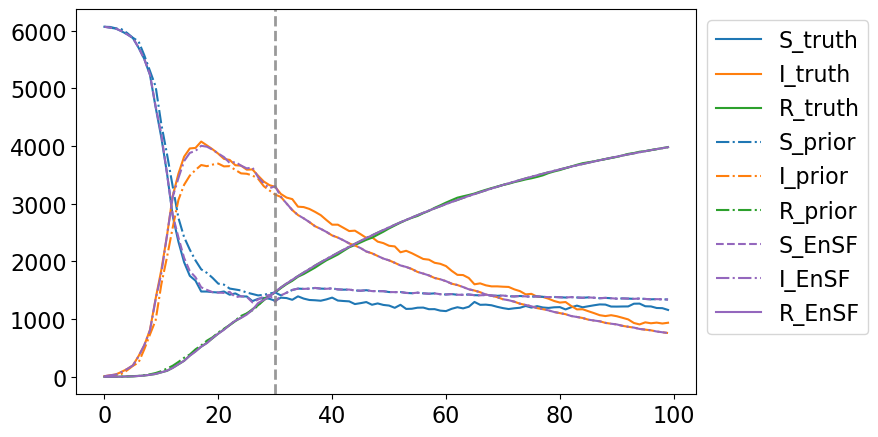

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(truth_state[:100,...,0].sum(axis=(1)),label = "S_truth",color='tab:blue', linestyle='-')
plt.plot(truth_state[:100,...,1].sum(axis=(1)),label = "I_truth", color='tab:orange', linestyle='-')
plt.plot(truth_state[:100,...,2].sum(axis=(1)),label = "R_truth", color='tab:green', linestyle='-')
plt.plot(ens_prior[:100,...,0].mean(axis=1).sum(axis=(1)),label = "S_prior", color='tab:blue', linestyle='-.')
plt.plot(ens_prior[:100,...,1].mean(axis=1).sum(axis=(1)),label = "I_prior", color='tab:orange', linestyle='-.')
plt.plot(ens_prior[:100,...,2].mean(axis=1).sum(axis=(1)),label = "R_prior", color='tab:green', linestyle='-.')
plt.plot(ens_state[:100,...,0].mean(axis=1).sum(axis=(1)),label = "S_EnSF", color='tab:purple', linestyle='--')
plt.plot(ens_state[:100,...,1].mean(axis=1).sum(axis=(1)),label = "I_EnSF", color='tab:purple', linestyle='-.')
plt.plot(ens_state[:100,...,2].mean(axis=1).sum(axis=(1)),label = "R_EnSF", color='tab:purple', linestyle='-')
plt.axvline(x=30, color='grey', linestyle='--', alpha=0.8, linewidth=2)
# plt.text(15, 3800, 'DA Phase', ha='center', fontsize=12, 
#          bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
# plt.text(60, 3800, 'Prediction Phase', ha='center', fontsize=12,
#          bbox=dict(boxstyle="round,pad=0.4", facecolor="lightcyan", alpha=0.8))
#plt.title("ABM with DA (State and Parameter)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=16)
plt.tick_params(axis="both", labelsize=16)
plt.show()